# scMixology Seurat Workflow - V8


## Import and Setups


In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(SeuratObject)
  library(dplyr)
  library(ggplot2)
  library(patchwork)
  library(Matrix)
  library(data.table)
  library(mclust)
})

start_time <- Sys.time()

DATASET <- "scMixology"
VERSION <- "V8"
SEED <- 1234
set.seed(SEED)

BASE_DIR <- "/home/mtarzi/CEPH/scRNA_sequencing_scMixology_benchmarking"
OUT_DIR <- file.path(BASE_DIR, "seurat_outputs")
CELLRANGER_OUTS <- file.path(BASE_DIR, "cell_ranger", "SCMIXOLOGY")
MATRIX_DIR <- file.path(CELLRANGER_OUTS, "filtered_feature_bc_matrix")

TABLE_DIR <- file.path(OUT_DIR, VERSION, "tables")
FIGURE_DIR <- file.path(OUT_DIR, VERSION, "figures")
OBJECT_DIR <- file.path(OUT_DIR, VERSION, "objects")
COMMON_OBJECT_DIR <- file.path(OUT_DIR, "objects")
PREFILTER_OBJECT <- file.path(COMMON_OBJECT_DIR, paste0(DATASET, "_seurat_prefilter_with_cell_line_labels.rds"))

dir.create(TABLE_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIGURE_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(OBJECT_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(COMMON_OBJECT_DIR, recursive = TRUE, showWarnings = FALSE)

MIN_FEATURES <- 200
MIN_CELLS <- 3
MAX_FEATURES <- 6200
MAX_PERCENT_MT <- 5
MAX_COUNTS <- 60000
NORMALIZATION_METHOD <- "LogNormalize"
SCALE_FACTOR <- 10000
N_HVGS <- 2000
N_PCS <- 50
SELECTED_PCS <- 50
TSNE_N_PCS <- 50
TSNE_PERPLEXITY <- 18
N_NEIGHBORS <- 20
LOUVAIN_RES <- 0.1
LEIDEN_RES <- 0.08
FINAL_SELECTED_RESOLUTION <- 0.2
RESOLUTIONS <- seq(0.1, 2.0, by = 0.1)

resolution_key_1d <- function(resolution) {
  gsub("\\.", "", sprintf("%.1f", resolution))
}

resolution_key_free <- function(resolution) {
  key <- format(resolution, trim = TRUE, scientific = FALSE)
  key <- sub("0+$", "", key)
  key <- sub("\\.$", "", key)
  gsub("\\.", "", key)
}

FINAL_LOUVAIN_KEY <- paste0("louvain_res", resolution_key_1d(LOUVAIN_RES))
FINAL_LEIDEN_KEY <- paste0("leiden_res", resolution_key_free(LEIDEN_RES))
FINAL_CLUSTER_KEY <- FINAL_LEIDEN_KEY

analysis_parameters <- data.frame(
  parameter = c(
    "dataset", "version", "seed", "min_features", "min_cells", "max_features",
    "max_percent_mt", "max_counts", "normalization_method", "scale_factor",
    "n_hvgs", "n_pcs", "selected_pcs", "tsne_n_pcs", "tsne_perplexity",
    "n_neighbors", "louvain_resolution", "leiden_resolution", "final_cluster_key"
  ),
  value = c(
    DATASET, VERSION, SEED, MIN_FEATURES, MIN_CELLS, MAX_FEATURES,
    MAX_PERCENT_MT, MAX_COUNTS, NORMALIZATION_METHOD, SCALE_FACTOR,
    N_HVGS, N_PCS, SELECTED_PCS, TSNE_N_PCS, TSNE_PERPLEXITY,
    N_NEIGHBORS, LOUVAIN_RES, LEIDEN_RES, FINAL_CLUSTER_KEY
  )
)

write.csv(
  analysis_parameters,
  file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_analysis_parameters.csv")),
  row.names = FALSE
)

analysis_parameters


parameter,value
<chr>,<chr>
dataset,scMixology
version,V8
seed,1234
min_features,200
min_cells,3
max_features,6200
max_percent_mt,5
max_counts,60000
normalization_method,LogNormalize


## Load pre-filter Seurat object


In [2]:
if (!file.exists(PREFILTER_OBJECT)) {
  stop(paste("Pre-filtered labelled object not found:", PREFILTER_OBJECT))
}

data_obj <- readRDS(PREFILTER_OBJECT)

if (!"percent.mt" %in% colnames(data_obj@meta.data)) {
  data_obj[["percent.mt"]] <- PercentageFeatureSet(data_obj, pattern = "^MT-|^mt-")
}
if (!"percent.rps" %in% colnames(data_obj@meta.data)) {
  data_obj[["percent.rps"]] <- PercentageFeatureSet(data_obj, pattern = "^RPS|^Rps|^rps")
}
if (!"percent.rpl" %in% colnames(data_obj@meta.data)) {
  data_obj[["percent.rpl"]] <- PercentageFeatureSet(data_obj, pattern = "^RPL|^Rpl|^rpl")
}
if (!"known_label" %in% colnames(data_obj@meta.data)) {
  stop("known_label column not found in the pre-filtered object")
}

data_obj$known_label_plot <- as.character(data_obj$known_label)
data_obj$known_label_plot[is.na(data_obj$known_label_plot) | trimws(data_obj$known_label_plot) == ""] <- "unmatched"
data_obj$known_label_plot <- as.factor(data_obj$known_label_plot)

data_obj


An object of class Seurat 
38606 features across 4488 samples within 1 assay 
Active assay: RNA (38606 features, 0 variable features)
 1 layer present: counts

## QC Metrics before filtering


In [3]:
qc_summary_before <- data.frame(
  metric = c(
    "n_cells", "n_genes", "median_nFeature_RNA", "median_nCount_RNA",
    "median_percent_mt", "median_percent_rps", "median_percent_rpl",
    "n_cells_with_known_label", "n_cells_without_known_label"
  ),
  value = c(
    ncol(data_obj), nrow(data_obj),
    median(data_obj$nFeature_RNA, na.rm = TRUE),
    median(data_obj$nCount_RNA, na.rm = TRUE),
    median(data_obj$percent.mt, na.rm = TRUE),
    median(data_obj$percent.rps, na.rm = TRUE),
    median(data_obj$percent.rpl, na.rm = TRUE),
    sum(!is.na(data_obj$known_label)),
    sum(is.na(data_obj$known_label))
  )
)

write.csv(
  qc_summary_before,
  file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_qc_summary_before_filtering.csv")),
  row.names = FALSE
)

qc_summary_before


metric,value
<chr>,<dbl>
n_cells,4488.000000
n_genes,38606.000000
median_nFeature_RNA,5201.000000
median_nCount_RNA,25699.000000
median_percent_mt,4.889067
median_percent_rps,11.397218
median_percent_rpl,15.318231
n_cells_with_known_label,3916.000000
n_cells_without_known_label,572.000000


## Filtering


In [4]:
initial_cells <- ncol(data_obj)
initial_genes <- nrow(data_obj)

data_obj <- subset(
  data_obj,
  subset = nFeature_RNA >= MIN_FEATURES &
    nFeature_RNA <= MAX_FEATURES &
    percent.mt < MAX_PERCENT_MT &
    nCount_RNA < MAX_COUNTS
)

counts_mat <- GetAssayData(data_obj, assay = "RNA", layer = "counts")
genes_keep <- rowSums(counts_mat > 0) >= MIN_CELLS
data_obj <- subset(data_obj, features = names(genes_keep[genes_keep]))

data_obj$known_label_plot <- as.character(data_obj$known_label)
data_obj$known_label_plot[is.na(data_obj$known_label_plot) | trimws(data_obj$known_label_plot) == ""] <- "unmatched"
data_obj$known_label_plot <- as.factor(data_obj$known_label_plot)

filtering_summary <- data.frame(
  dataset = DATASET,
  version = VERSION,
  initial_cells = initial_cells,
  filtered_cells = ncol(data_obj),
  removed_cells = initial_cells - ncol(data_obj),
  initial_genes = initial_genes,
  filtered_genes = nrow(data_obj),
  removed_genes = initial_genes - nrow(data_obj),
  min_features = MIN_FEATURES,
  max_features = MAX_FEATURES,
  max_percent_mt = MAX_PERCENT_MT,
  max_counts = MAX_COUNTS,
  min_cells = MIN_CELLS,
  cells_with_known_label = sum(!is.na(data_obj$known_label)),
  cells_without_known_label = sum(is.na(data_obj$known_label))
)

write.csv(
  filtering_summary,
  file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_filtering_summary.csv")),
  row.names = FALSE
)

filtering_summary


dataset,version,initial_cells,filtered_cells,removed_cells,initial_genes,filtered_genes,removed_genes,min_features,max_features,max_percent_mt,max_counts,min_cells,cells_with_known_label,cells_without_known_label
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
scMixology,V8,4488,1637,2851,38606,23282,15324,200,6200,5,60000,3,1531,106


## QC Metrics and Plots after filtering


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


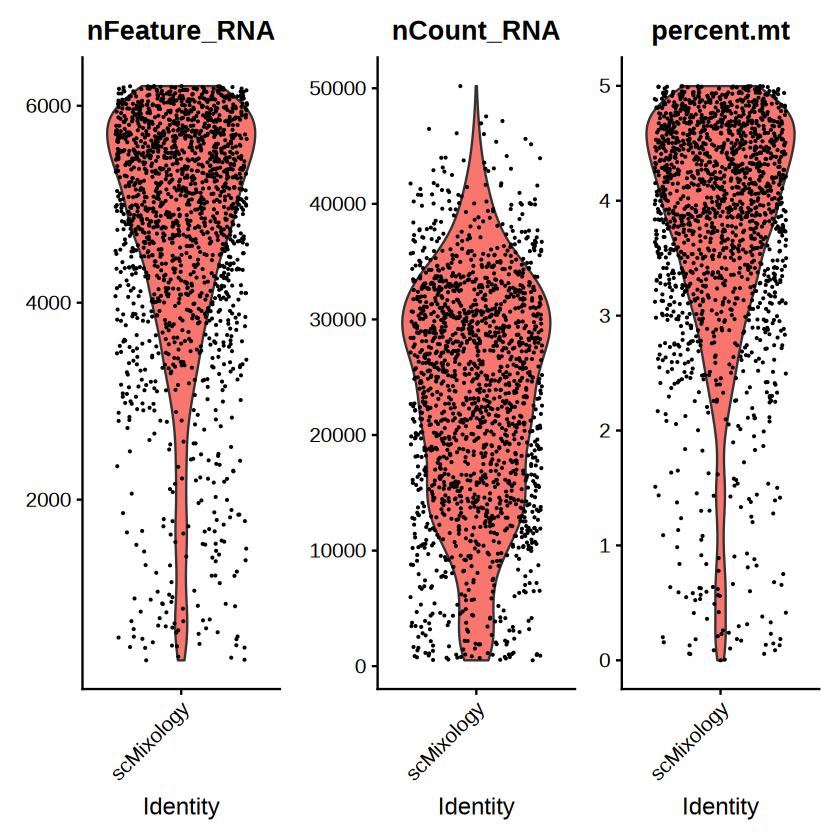

In [5]:
p_qc <- VlnPlot(
  data_obj,
  features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
  ncol = 3,
  pt.size = 0.1
)

ggsave(
  filename = file.path(FIGURE_DIR, paste0(DATASET, "_seurat_", VERSION, "_qc_violin_after_filtering.png")),
  plot = p_qc,
  width = 12,
  height = 5,
  dpi = 300
)

p_qc


## Normalization and Highly Variable Genes


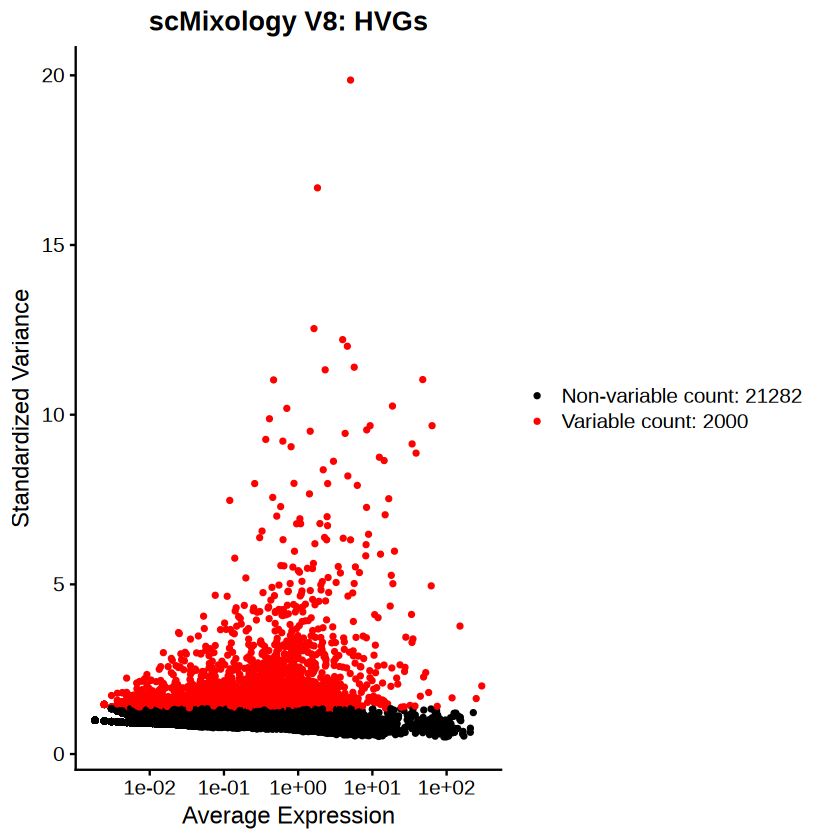

In [6]:
set.seed(SEED)

data_obj <- NormalizeData(
  data_obj,
  normalization.method = NORMALIZATION_METHOD,
  scale.factor = SCALE_FACTOR,
  verbose = FALSE
)

data_obj <- FindVariableFeatures(
  data_obj,
  selection.method = "vst",
  nfeatures = N_HVGS,
  verbose = FALSE
)

hvg_table <- data.frame(
  gene = VariableFeatures(data_obj),
  rank = seq_along(VariableFeatures(data_obj))
)

write.csv(
  hvg_table,
  file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_highly_variable_genes.csv")),
  row.names = FALSE
)

p_hvg <- VariableFeaturePlot(data_obj) + ggtitle(paste0(DATASET, " ", VERSION, ": HVGs"))

ggsave(
  filename = file.path(FIGURE_DIR, paste0(DATASET, "_seurat_", VERSION, "_HVGs.png")),
  plot = p_hvg,
  width = 8,
  height = 6,
  dpi = 300
)

p_hvg


## Scaling and PCA


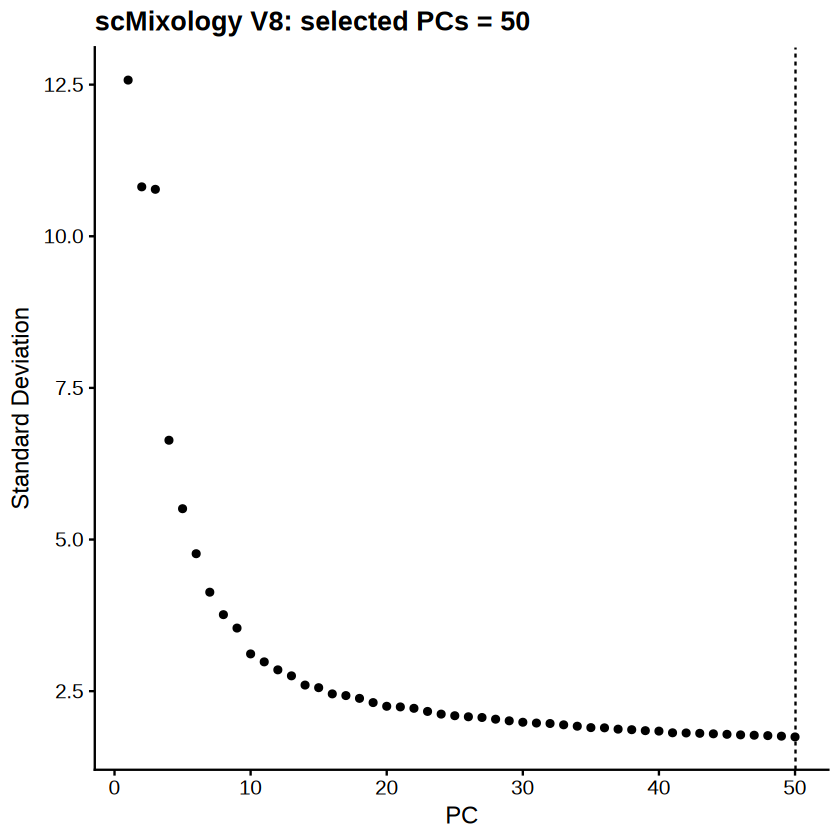

In [7]:
set.seed(SEED)

data_obj <- ScaleData(
  data_obj,
  features = rownames(data_obj),
  verbose = FALSE
)

data_obj <- RunPCA(
  data_obj,
  features = VariableFeatures(data_obj),
  npcs = N_PCS,
  verbose = FALSE
)

p_elbow <- ElbowPlot(data_obj, ndims = min(N_PCS, 100)) +
  geom_vline(xintercept = SELECTED_PCS, linetype = "dashed") +
  ggtitle(paste0(DATASET, " ", VERSION, ": selected PCs = ", SELECTED_PCS))

ggsave(
  filename = file.path(FIGURE_DIR, paste0(DATASET, "_seurat_", VERSION, "_PCA_elbow.png")),
  plot = p_elbow,
  width = 8,
  height = 6,
  dpi = 300
)

p_elbow


## UMAP and t-SNE


In [8]:
SIG_PCS <- 1:min(SELECTED_PCS, N_PCS)
TSNE_PCS <- 1:min(TSNE_N_PCS, N_PCS)

set.seed(SEED)

data_obj <- FindNeighbors(
  data_obj,
  dims = SIG_PCS,
  reduction = "pca",
  k.param = N_NEIGHBORS
)

set.seed(SEED)

data_obj <- RunUMAP(
  data_obj,
  dims = SIG_PCS,
  reduction = "pca",
  umap.method = "uwot",
  metric = "cosine",
  seed.use = SEED
)

set.seed(SEED)

data_obj <- RunTSNE(
  data_obj,
  dims = TSNE_PCS,
  reduction = "pca",
  perplexity = TSNE_PERPLEXITY,
  seed.use = SEED
)

data_obj


Computing nearest neighbor graph

Computing SNN

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
09:21:58 UMAP embedding parameters a = 0.9922 b = 1.112

09:21:58 Read 1637 rows and found 50 numeric columns

09:21:58 Using Annoy for neighbor search, n_neighbors = 30

09:21:58 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

09:21:58 Writing NN index file to temp file /tmp/Rtmpt686v6/file706a3574f00a

09:21:58 Searching Annoy index using 1 thread, search_k = 3000

09:21:58 Annoy recall = 100%

09:21:59 Commencing smooth kNN distance cali

An object of class Seurat 
23282 features across 1637 samples within 1 assay 
Active assay: RNA (23282 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

## Clustering across resolutions


In [9]:
clustering_summary <- data.frame()

for (res in RESOLUTIONS) {
  res_key <- resolution_key_1d(res)

  set.seed(SEED)
  data_obj <- FindClusters(
    data_obj,
    algorithm = 1,
    resolution = res,
    verbose = FALSE
  )
  louvain_col <- paste0("louvain_res", res_key)
  data_obj@meta.data[[louvain_col]] <- as.character(Idents(data_obj))

  set.seed(SEED)
  data_obj <- FindClusters(
    data_obj,
    algorithm = 4,
    resolution = res,
    verbose = FALSE
  )
  leiden_col <- paste0("leiden_res", res_key)
  data_obj@meta.data[[leiden_col]] <- as.character(Idents(data_obj))

  clustering_summary <- rbind(
    clustering_summary,
    data.frame(
      resolution = res,
      louvain_key = louvain_col,
      louvain_n_clusters = length(unique(data_obj@meta.data[[louvain_col]])),
      leiden_key = leiden_col,
      leiden_n_clusters = length(unique(data_obj@meta.data[[leiden_col]]))
    )
  )
}

write.csv(
  clustering_summary,
  file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_clustering_summary_all_resolutions.csv")),
  row.names = FALSE
)

clustering_summary


Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1.”
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1.”
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1.”
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1.”
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clu

resolution,louvain_key,louvain_n_clusters,leiden_key,leiden_n_clusters
<dbl>,<chr>,<int>,<chr>,<int>
0.1,louvain_res01,6,leiden_res01,5
0.2,louvain_res02,6,leiden_res02,5
0.3,louvain_res03,7,leiden_res03,6
0.4,louvain_res04,8,leiden_res04,6
0.5,louvain_res05,8,leiden_res05,6
0.6,louvain_res06,9,leiden_res06,7
0.7,louvain_res07,9,leiden_res07,7
0.8,louvain_res08,10,leiden_res08,8
0.9,louvain_res09,11,leiden_res09,8


## Final clustering


In [10]:
set.seed(SEED)
data_obj <- FindClusters(
  data_obj,
  algorithm = 1,
  resolution = LOUVAIN_RES,
  verbose = FALSE
)
data_obj@meta.data[[FINAL_LOUVAIN_KEY]] <- as.character(Idents(data_obj))

set.seed(SEED)
data_obj <- FindClusters(
  data_obj,
  algorithm = 4,
  resolution = LEIDEN_RES,
  verbose = FALSE
)
data_obj@meta.data[[FINAL_LEIDEN_KEY]] <- as.character(Idents(data_obj))

data_obj$final_clusters <- as.character(data_obj@meta.data[[FINAL_CLUSTER_KEY]])
Idents(data_obj) <- "final_clusters"

cluster_summary_final <- data.frame(
  method = c("Louvain_algorithm1", "Leiden_algorithm4", "final_clusters"),
  resolution = c(LOUVAIN_RES, LEIDEN_RES, LEIDEN_RES),
  cluster_column = c(FINAL_LOUVAIN_KEY, FINAL_LEIDEN_KEY, "final_clusters"),
  n_clusters = c(
    length(unique(data_obj@meta.data[[FINAL_LOUVAIN_KEY]])),
    length(unique(data_obj@meta.data[[FINAL_LEIDEN_KEY]])),
    length(unique(data_obj$final_clusters))
  )
)

write.csv(
  cluster_summary_final,
  file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_final_clustering_summary.csv")),
  row.names = FALSE
)

cluster_summary_final


Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
“`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1.”


method,resolution,cluster_column,n_clusters
<chr>,<dbl>,<chr>,<int>
Louvain_algorithm1,0.10,louvain_res01,6
Leiden_algorithm4,0.08,leiden_res008,5
final_clusters,0.08,final_clusters,5


## UMAP and t-SNE Plots


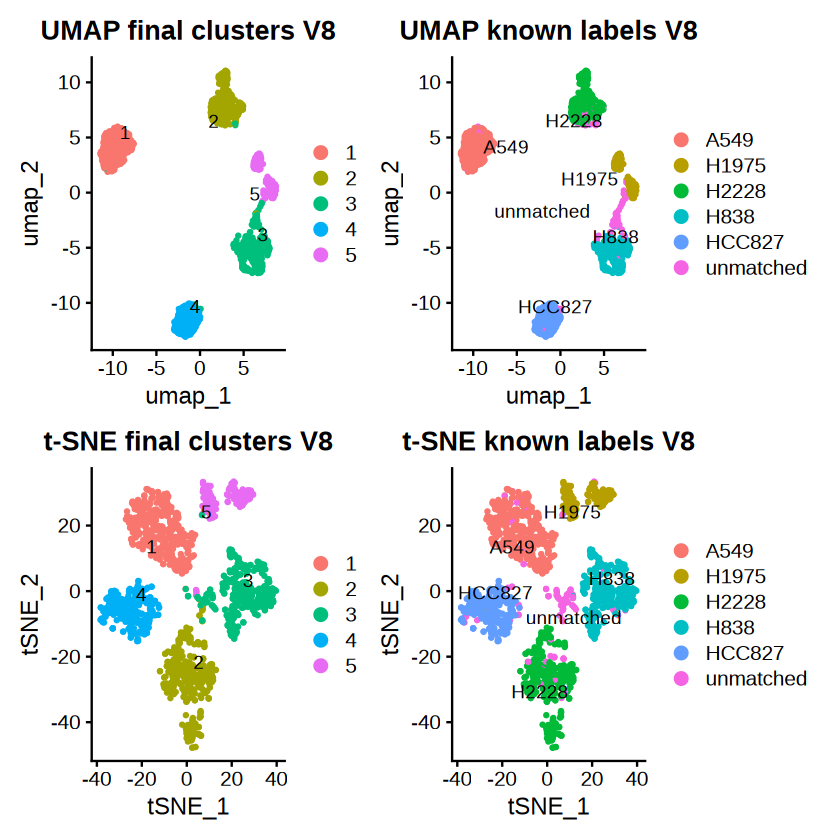

In [11]:
p_umap_clusters <- DimPlot(
  data_obj,
  reduction = "umap",
  group.by = "final_clusters",
  label = TRUE,
  repel = TRUE,
  pt.size = 0.6
) + ggtitle(paste0("UMAP final clusters ", VERSION))

p_umap_label <- DimPlot(
  data_obj,
  reduction = "umap",
  group.by = "known_label_plot",
  label = TRUE,
  repel = TRUE,
  pt.size = 0.6
) + ggtitle(paste0("UMAP known labels ", VERSION))

p_tsne_clusters <- DimPlot(
  data_obj,
  reduction = "tsne",
  group.by = "final_clusters",
  label = TRUE,
  repel = TRUE,
  pt.size = 0.6
) + ggtitle(paste0("t-SNE final clusters ", VERSION))

p_tsne_label <- DimPlot(
  data_obj,
  reduction = "tsne",
  group.by = "known_label_plot",
  label = TRUE,
  repel = TRUE,
  pt.size = 0.6
) + ggtitle(paste0("t-SNE known labels ", VERSION))

p_umap_combined <- p_umap_clusters | p_umap_label
p_tsne_combined <- p_tsne_clusters | p_tsne_label
p_all_dimred <- p_umap_combined / p_tsne_combined

ggsave(
  filename = file.path(FIGURE_DIR, paste0(DATASET, "_seurat_", VERSION, "_umap_tsne_clusters_known_labels.png")),
  plot = p_all_dimred,
  width = 14,
  height = 12,
  dpi = 300
)

p_all_dimred


## Thesis-style UMAP


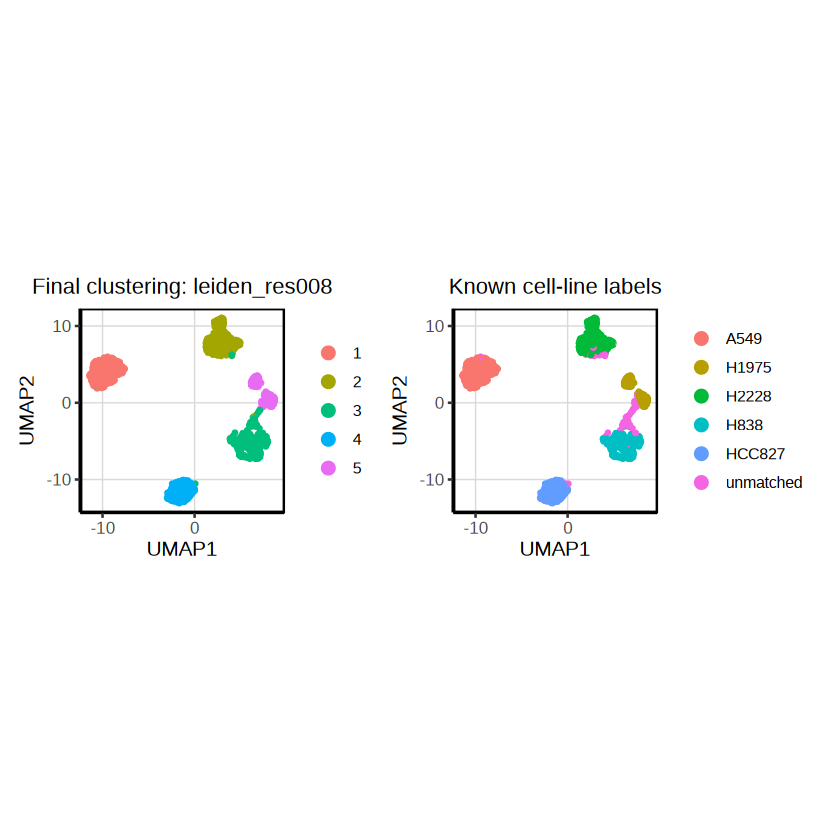

In [12]:
# Thesis-style UMAP: final clustering vs known cell-line labels
if (!"final_clusters" %in% colnames(data_obj@meta.data)) {
  data_obj$final_clusters <- as.character(data_obj@meta.data[[FINAL_CLUSTER_KEY]])
}

if (!"known_label_plot" %in% colnames(data_obj@meta.data)) {
  data_obj$known_label_plot <- as.character(data_obj$known_label)
  data_obj$known_label_plot[
    is.na(data_obj$known_label_plot) |
      trimws(data_obj$known_label_plot) == ""
  ] <- "unmatched"
  data_obj$known_label_plot <- as.factor(data_obj$known_label_plot)
}

theme_umap_thesis <- theme_classic(base_size = 12) +
  theme(
    aspect.ratio = 1,
    plot.title = element_text(hjust = 0.5, size = 13),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.8),
    panel.grid.major = element_line(color = "grey85", linewidth = 0.3),
    panel.grid.minor = element_blank(),
    legend.title = element_blank(),
    legend.text = element_text(size = 9)
  )

p_umap_final_clusters_thesis <- DimPlot(
  data_obj,
  reduction = "umap",
  group.by = "final_clusters",
  label = FALSE,
  pt.size = 0.7
) +
  labs(
    title = paste0("Final clustering: ", FINAL_CLUSTER_KEY),
    x = "UMAP1",
    y = "UMAP2"
  ) +
  scale_x_continuous(breaks = c(-10, 0, 10)) +
  scale_y_continuous(breaks = c(-10, 0, 10)) +
  coord_fixed() +
  theme_umap_thesis

p_umap_known_labels_thesis <- DimPlot(
  data_obj,
  reduction = "umap",
  group.by = "known_label_plot",
  label = FALSE,
  pt.size = 0.7
) +
  labs(
    title = "Known cell-line labels",
    x = "UMAP1",
    y = "UMAP2"
  ) +
  scale_x_continuous(breaks = c(-10, 0, 10)) +
  scale_y_continuous(breaks = c(-10, 0, 10)) +
  coord_fixed() +
  theme_umap_thesis

p_umap_thesis <- p_umap_final_clusters_thesis | p_umap_known_labels_thesis

p_umap_thesis

ggsave(
  filename = file.path(
    FIGURE_DIR,
    paste0(DATASET, "_seurat_", VERSION, "_UMAP_final_clustering_vs_known_labels_thesis.png")
  ),
  plot = p_umap_thesis,
  width = 12,
  height = 6,
  dpi = 300
)

## ARI for selected clustering resolution


In [13]:
invalid_labels <- c("", "<na>", "nan", "na", "none", "unknown", "unmatched")
known_labels <- trimws(as.character(data_obj$known_label))
known_labels[is.na(known_labels)] <- ""
valid_labels <- !tolower(known_labels) %in% invalid_labels & known_labels != ""

final_res_key <- resolution_key_1d(FINAL_SELECTED_RESOLUTION)
cluster_methods <- list(
  Louvain = paste0("louvain_res", final_res_key),
  Leiden = paste0("leiden_res", final_res_key)
)

ari_results <- list()

for (method_name in names(cluster_methods)) {
  cluster_key <- cluster_methods[[method_name]]
  if (!cluster_key %in% colnames(data_obj@meta.data)) next
  clusters <- trimws(as.character(data_obj@meta.data[[cluster_key]]))
  clusters[is.na(clusters)] <- ""
  valid_cells <- valid_labels & clusters != ""
  true_labels <- known_labels[valid_cells]
  predicted_clusters <- clusters[valid_cells]
  ari_value <- if (sum(valid_cells) > 0) mclust::adjustedRandIndex(true_labels, predicted_clusters) else NA_real_

  ari_results[[method_name]] <- data.frame(
    dataset = DATASET,
    version = VERSION,
    method = method_name,
    resolution = FINAL_SELECTED_RESOLUTION,
    cluster_key = cluster_key,
    cells_used = sum(valid_cells),
    n_clusters = length(unique(predicted_clusters)),
    ARI = ari_value
  )
}

ari_table <- dplyr::bind_rows(ari_results)

write.csv(
  ari_table,
  file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_ARI_resolution_", FINAL_SELECTED_RESOLUTION, ".csv")),
  row.names = FALSE
)

ari_table


dataset,version,method,resolution,cluster_key,cells_used,n_clusters,ARI
<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<int>,<dbl>
scMixology,V8,Louvain,0.2,louvain_res02,1531,6,0.9793189
scMixology,V8,Leiden,0.2,leiden_res02,1531,5,0.9989168


## ARI across clustering resolutions


dataset,version,resolution,method,cluster_key,n_clusters,cells_used,ARI
<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<int>,<dbl>
scMixology,V8,0.1,Louvain,louvain_res01,6,1531,0.9823910
scMixology,V8,0.1,Leiden,leiden_res01,5,1531,0.9989168
scMixology,V8,0.2,Louvain,louvain_res02,6,1531,0.9793189
scMixology,V8,0.2,Leiden,leiden_res02,5,1531,0.9989168
scMixology,V8,0.3,Louvain,louvain_res03,7,1531,0.9276362
scMixology,V8,0.3,Leiden,leiden_res03,6,1531,0.9823910
scMixology,V8,0.4,Louvain,louvain_res04,8,1531,0.9282482
scMixology,V8,0.4,Leiden,leiden_res04,6,1531,0.9793189
scMixology,V8,0.5,Louvain,louvain_res05,8,1531,0.9282482


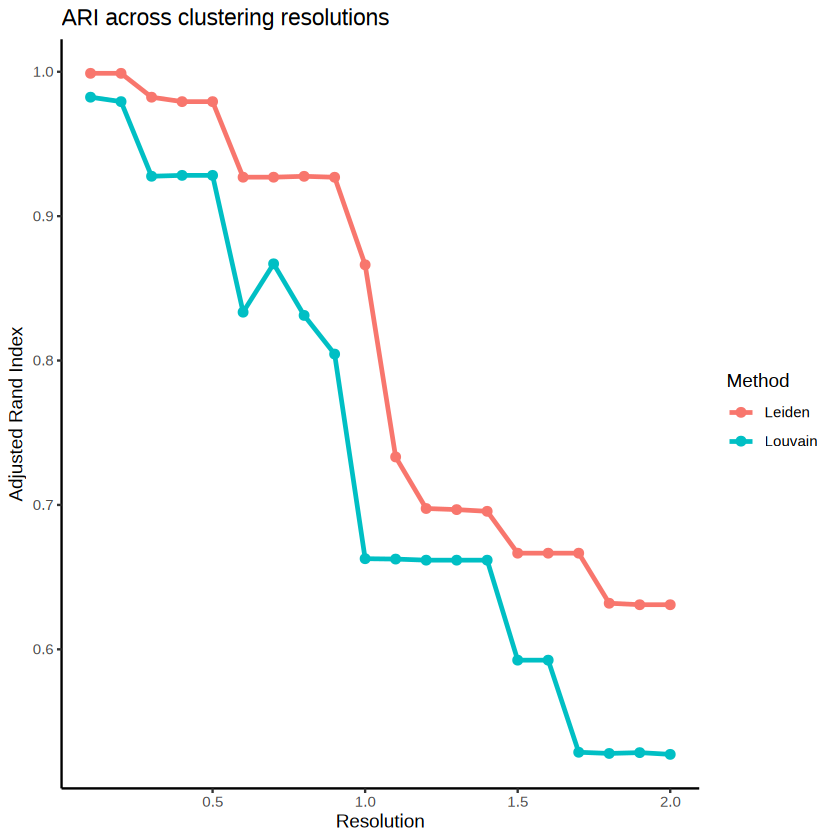

In [14]:
ari_resolution_results <- list()

for (res in RESOLUTIONS) {
  res_key <- resolution_key_1d(res)
  cluster_methods_res <- list(
    Louvain = paste0("louvain_res", res_key),
    Leiden = paste0("leiden_res", res_key)
  )

  for (method_name in names(cluster_methods_res)) {
    cluster_key <- cluster_methods_res[[method_name]]
    if (!cluster_key %in% colnames(data_obj@meta.data)) next
    clusters <- trimws(as.character(data_obj@meta.data[[cluster_key]]))
    clusters[is.na(clusters)] <- ""
    valid_cells <- valid_labels & clusters != ""
    true_labels <- known_labels[valid_cells]
    predicted_clusters <- clusters[valid_cells]
    ari_value <- if (sum(valid_cells) > 0) mclust::adjustedRandIndex(true_labels, predicted_clusters) else NA_real_

    ari_resolution_results[[length(ari_resolution_results) + 1]] <- data.frame(
      dataset = DATASET,
      version = VERSION,
      resolution = res,
      method = method_name,
      cluster_key = cluster_key,
      n_clusters = length(unique(predicted_clusters)),
      cells_used = sum(valid_cells),
      ARI = ari_value
    )
  }
}

ari_resolution_table <- dplyr::bind_rows(ari_resolution_results)

write.csv(
  ari_resolution_table,
  file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_ARI_across_resolutions.csv")),
  row.names = FALSE
)

p_ari_resolution <- ggplot(
  ari_resolution_table,
  aes(x = resolution, y = ARI, color = method, group = method)
) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(title = "ARI across clustering resolutions", x = "Resolution", y = "Adjusted Rand Index", color = "Method") +
  theme_classic()

ggsave(
  filename = file.path(FIGURE_DIR, paste0(DATASET, "_seurat_", VERSION, "_ARI_across_resolutions.png")),
  plot = p_ari_resolution,
  width = 8,
  height = 5,
  dpi = 300
)

ari_resolution_table
p_ari_resolution


## Marker Genes


Calculating cluster 2

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session

Calculating cluster 1

Calculating cluster 4

Calculating cluster 3

Calculating cluster 5



,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
HLA-DRB1,3.340014e-268,6.637641,0.929,0.068,7.776221e-264,2,HLA-DRB1
CLDN11,9.089857e-268,4.513107,0.916,0.052,2.116300e-263,2,CLDN11
CDH11,2.077847e-264,7.284252,0.840,0.017,4.837644e-260,2,CDH11
ENSG00000223829,3.085309e-256,5.970216,0.860,0.035,7.183217e-252,2,ENSG00000223829
HLA-DRB5,9.062084e-256,7.185605,0.827,0.022,2.109834e-251,2,HLA-DRB5
HLA-DRA,5.208532e-254,6.825475,0.880,0.054,1.212651e-249,2,HLA-DRA


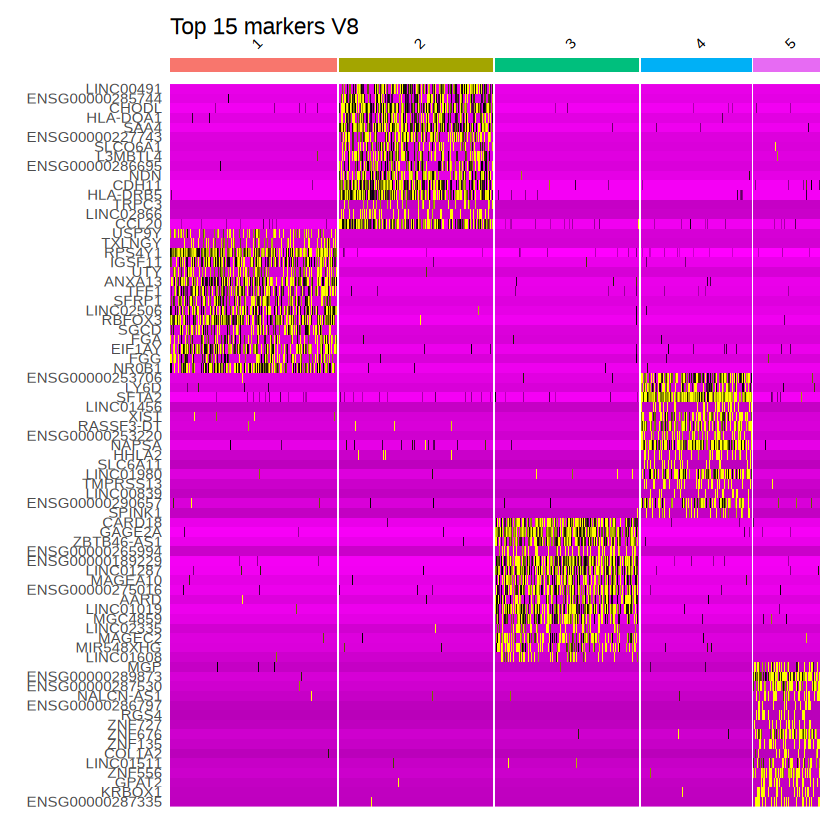

In [15]:
DefaultAssay(data_obj) <- "RNA"
Idents(data_obj) <- "final_clusters"

markers <- FindAllMarkers(
  data_obj,
  assay = "RNA",
  only.pos = TRUE,
  test.use = "wilcox",
  logfc.threshold = 0.25,
  min.pct = 0.1
)

markers_filtered <- markers %>%
  dplyr::filter(p_val_adj < 0.01, avg_log2FC > 0.25)

top15_markers <- markers_filtered %>%
  dplyr::arrange(cluster, -avg_log2FC) %>%
  dplyr::group_by(cluster) %>%
  dplyr::slice_head(n = 15) %>%
  dplyr::ungroup()

top15_genes <- unique(top15_markers$gene)
top15_genes <- top15_genes[top15_genes %in% rownames(data_obj)]

write.csv(
  markers,
  file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_all_cluster_markers.csv")),
  row.names = FALSE
)

write.csv(
  markers_filtered,
  file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_filtered_cluster_markers.csv")),
  row.names = FALSE
)

write.csv(
  top15_markers,
  file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_top15_markers.csv")),
  row.names = FALSE
)

p_heatmap <- DoHeatmap(
  data_obj,
  features = top15_genes,
  group.by = "final_clusters",
  size = 3
) + NoLegend() + ggtitle(paste0("Top 15 markers ", VERSION))

ggsave(
  filename = file.path(FIGURE_DIR, paste0(DATASET, "_seurat_", VERSION, "_top15_marker_heatmap.png")),
  plot = p_heatmap,
  width = 12,
  height = 10,
  dpi = 300
)

head(markers_filtered)
p_heatmap


## Save final object and Reproducibility


In [16]:
final_object_file <- file.path(
  OBJECT_DIR,
  paste0(DATASET, "_seurat_", VERSION, "_processed_final.rds")
)

saveRDS(data_obj, final_object_file)

total_runtime_seconds <- as.numeric(difftime(Sys.time(), start_time, units = "secs"))

total_runtime <- data.frame(
  dataset = DATASET,
  version = VERSION,
  total_runtime_seconds = total_runtime_seconds,
  total_runtime_minutes = total_runtime_seconds / 60
)

write.csv(
  total_runtime,
  file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_total_runtime.csv")),
  row.names = FALSE
)

important_packages <- c("Seurat", "SeuratObject", "sctransform", "Matrix", "dplyr", "ggplot2", "patchwork", "data.table", "mclust")

package_versions <- data.frame(
  package = important_packages,
  version = sapply(important_packages, function(pkg) {
    if (requireNamespace(pkg, quietly = TRUE)) as.character(packageVersion(pkg)) else "not installed"
  }),
  row.names = NULL
)

write.csv(
  package_versions,
  file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_package_versions.csv")),
  row.names = FALSE
)

reproducibility_info <- data.frame(
  dataset = DATASET,
  version = VERSION,
  seed = SEED,
  r_version = paste(R.version$major, R.version$minor, sep = "."),
  platform = R.version$platform,
  operating_system = R.version$os,
  final_object_file = final_object_file,
  stringsAsFactors = FALSE
)

write.csv(
  reproducibility_info,
  file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_reproducibility_info.csv")),
  row.names = FALSE
)

sink(file.path(TABLE_DIR, paste0(DATASET, "_seurat_", VERSION, "_sessionInfo.txt")))
sessionInfo()
sink()

total_runtime
package_versions
reproducibility_info


R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 19.04

Matrix products: default
BLAS/LAPACK: /15K/home-dist/home/mtarzi/.conda/envs/scRNA-R/lib/libopenblasp-r0.3.34.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] future_1.67.0      mclust_6.1.1       data.table_1.17.8  Matrix_1.6-5      
 [5] patchwork_1.3.2    ggplot2_3.5.2      dplyr_1.1.4        Seurat_5.3.0      
 [9] SeuratObject_5.2.0 sp_2.2-0          

loaded via a 

dataset,version,total_runtime_seconds,total_runtime_minutes
<chr>,<chr>,<dbl>,<dbl>
scMixology,V8,293.8466,4.897444


package,version
<chr>,<chr>
Seurat,5.3.0
SeuratObject,5.2.0
sctransform,0.4.2
Matrix,1.6.5
dplyr,1.1.4
ggplot2,3.5.2
patchwork,1.3.2
data.table,1.17.8
mclust,6.1.1


dataset,version,seed,r_version,platform,operating_system,final_object_file
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
scMixology,V8,1234,4.3.3,x86_64-conda-linux-gnu,linux-gnu,/home/mtarzi/CEPH/scRNA_sequencing_scMixology_benchmarking/seurat_outputs/V8/objects/scMixology_seurat_V8_processed_final.rds
